In [43]:
# Compare CWT: xsmurf FFTW vs MLX implementation
# Tests both Gaussian (g1) and Mexican hat (g2) wavelets
import numpy as np
import matplotlib.pyplot as plt
import mlx.core as mx
from numpy.fft import fftfreq
import xsmurf_wrapper as xsm

%matplotlib inline

ASTER SWIR Band4: (2100, 2048) -> cropped to (2048, 2048)
Range: [16, 196]


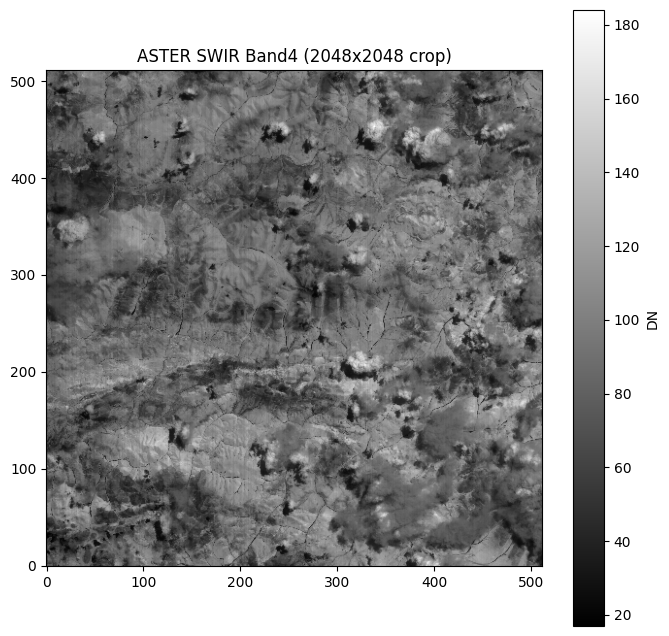

In [44]:
# Cell 2 - Load ASTER SWIR band, crop to 2048x2048 (power of 2 for gfft)
from pyhdf.SD import SD

hdf_path = '/Users/amasaryk/Documents/PS_venv/ASTER/WA/AST_L1A_00304202002045413_20241023115456_1582183.hdf'
f = SD(hdf_path)
ds = f.select(56)  # SWIR Band 4
full_image = ds[:].astype(np.float32)
ds.endaccess()
f.end()

# Crop to 2048x2048 from center
cy, cx = full_image.shape[0]//2, full_image.shape[1]//2
image = full_image[cy-1024:cy+1024, cx-1024:cx+1024]
N = image.shape[0]
ny, nx = image.shape

print(f'ASTER SWIR Band4: {full_image.shape} -> cropped to {image.shape}')
print(f'Range: [{image.min():.0f}, {image.max():.0f}]')
plt.figure(figsize=(8,8))
plt.imshow(image[::4, ::4], origin='lower', cmap='gray', rasterized=True)
plt.colorbar(label='DN')
plt.title(f'ASTER SWIR Band4 ({N}x{N} crop)')
plt.show()

In [45]:
# ===== CWT at 4 octaves x 4 voices — xsmurf gfft vs MLX =====
n_oct = 4
n_vox = 4
norm_factor = 6.0 / 0.86

scales_test = []
for o in range(n_oct):
    for v in range(n_vox):
        scales_test.append(norm_factor * 2.0 ** (o + v / n_vox))

# --- xsmurf gfft ---
img_xsm = xsm.XImage.from_numpy(image)
fft_xsm = xsm.igfft(img_xsm)

mod_xsm = []
arg_xsm = []
for i, s in enumerate(scales_test):
    dx_c = xsm.iconvol(fft_xsm, "0", "x*exp(-x*x-y*y)", s)
    dx_img = xsm.igifft(dx_c)
    dy_c = xsm.iconvol(fft_xsm, "0", "y*exp(-x*x-y*y)", s)
    dy_img = xsm.igifft(dy_c)
    m = xsm.gmod(dx_img, dy_img).to_numpy()
    a = xsm.garg(dx_img, dy_img).to_numpy()
    mod_xsm.append(m)
    arg_xsm.append(a)
    if i % 4 == 0:
        print(f'  xsmurf scale {i}: a={s:.1f}, mod range [{m.min():.4f}, {m.max():.4f}]')

# --- MLX (no 2pi, no swap) ---
kx_np = fftfreq(nx)
ky_np = fftfreq(ny)
KX_np, KY_np = np.meshgrid(kx_np, ky_np)
image_fft_mlx = mx.fft.fft2(mx.array(image))

mod_mlx = []
arg_mlx = []
for i, s in enumerate(scales_test):
    KX = mx.array((KX_np * s).astype(np.float32))
    KY = mx.array((KY_np * s).astype(np.float32))
    gauss = mx.exp(-(KX * KX + KY * KY))
    psi_dx = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                 np.array(KX * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    psi_dy = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                 np.array(KY * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    dx_m = np.array(mx.fft.ifft2(image_fft_mlx * psi_dx).real)
    dy_m = np.array(mx.fft.ifft2(image_fft_mlx * psi_dy).real)
    m = np.sqrt(dx_m**2 + dy_m**2).astype(np.float32)
    a = np.arctan2(dy_m, dx_m).astype(np.float32)
    mod_mlx.append(m)
    arg_mlx.append(a)
    if i % 4 == 0:
        print(f'  MLX    scale {i}: a={s:.1f}, mod range [{m.min():.4f}, {m.max():.4f}]')

print(f'\n{len(scales_test)} scales computed')

  xsmurf scale 0: a=7.0, mod range [0.0006, 24.5551]
  xsmurf scale 4: a=14.0, mod range [0.0009, 25.2290]
  xsmurf scale 8: a=27.9, mod range [0.0011, 25.3289]
  xsmurf scale 12: a=55.8, mod range [0.0014, 28.0442]
  MLX    scale 0: a=7.0, mod range [0.0005, 24.5553]
  MLX    scale 4: a=14.0, mod range [0.0009, 25.2292]
  MLX    scale 8: a=27.9, mod range [0.0011, 25.3291]
  MLX    scale 12: a=55.8, mod range [0.0014, 28.0445]

16 scales computed


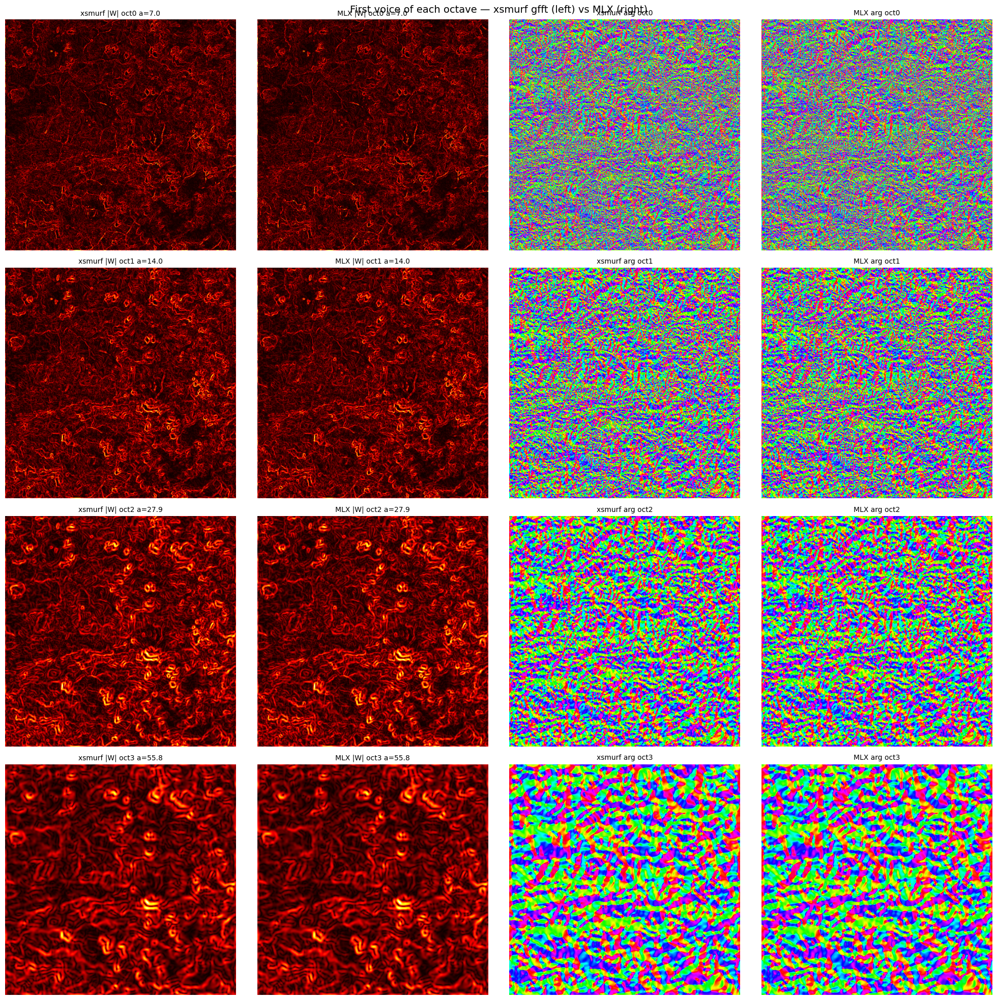


Numerical comparison (first voice of each octave):
Oct    Scale   xsmurf max      MLX max    Ratio     Corr
  0      7.0    24.555061    24.555300   1.0000 1.000000
  1     14.0    25.228975    25.229218   1.0000 1.000000
  2     27.9    25.328899    25.329079   1.0000 1.000000
  3     55.8    28.044231    28.044458   1.0000 1.000000


In [46]:
# ===== Plot first voice of each octave: xsmurf vs MLX =====
# Octave starts at indices 0, 4, 8, 12
ds = max(1, N // 500)  # downsample for display

fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for row, oct_idx in enumerate([0, 4, 8, 12]):
    s = scales_test[oct_idx]
    
    # xsmurf mod
    axes[row, 0].imshow(mod_xsm[oct_idx][::ds, ::ds], origin='lower', cmap='hot', rasterized=True)
    axes[row, 0].set_title(f'xsmurf |W| oct{row} a={s:.1f}', fontsize=10)
    
    # MLX mod
    axes[row, 1].imshow(mod_mlx[oct_idx][::ds, ::ds], origin='lower', cmap='hot', rasterized=True)
    axes[row, 1].set_title(f'MLX |W| oct{row} a={s:.1f}', fontsize=10)
    
    # xsmurf arg
    axes[row, 2].imshow(arg_xsm[oct_idx][::ds, ::ds], origin='lower', cmap='hsv', 
                         vmin=-np.pi, vmax=np.pi, rasterized=True)
    axes[row, 2].set_title(f'xsmurf arg oct{row}', fontsize=10)
    
    # MLX arg
    axes[row, 3].imshow(arg_mlx[oct_idx][::ds, ::ds], origin='lower', cmap='hsv',
                         vmin=-np.pi, vmax=np.pi, rasterized=True)
    axes[row, 3].set_title(f'MLX arg oct{row}', fontsize=10)
    
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('First voice of each octave — xsmurf gfft (left) vs MLX (right)', fontsize=14)
plt.tight_layout()
plt.show()

# Print numerical comparison
print('\nNumerical comparison (first voice of each octave):')
print(f'{"Oct":>3} {"Scale":>8} {"xsmurf max":>12} {"MLX max":>12} {"Ratio":>8} {"Corr":>8}')
for row, oct_idx in enumerate([0, 4, 8, 12]):
    s = scales_test[oct_idx]
    mx_val = mod_xsm[oct_idx].max()
    ml_val = mod_mlx[oct_idx].max()
    ratio = ml_val / mx_val if mx_val > 0 else float('nan')
    corr = np.corrcoef(mod_xsm[oct_idx].ravel(), mod_mlx[oct_idx].ravel())[0,1]
    print(f'{row:3d} {s:8.1f} {mx_val:12.6f} {ml_val:12.6f} {ratio:8.4f} {corr:8.6f}')

In [48]:
# ===== MLX CWT — OLD way (with 2*pi, no x↔y swap) =====
kx_old = fftfreq(nx) * 2 * np.pi  # angular frequency
ky_old = fftfreq(ny) * 2 * np.pi
KX_old, KY_old = np.meshgrid(kx_old, ky_old)
KX_o = mx.array((KX_old * scale).astype(np.float32))
KY_o = mx.array((KY_old * scale).astype(np.float32))

gauss_old = mx.exp(-(KX_o * KX_o + KY_o * KY_o))

# Old: NO x↔y swap (dx uses KX, dy uses KY)
psi_dx_old = mx.array(np.stack([np.zeros_like(np.array(gauss_old)),
                                 np.array(KX_o * gauss_old)], axis=-1)).view(mx.complex64).squeeze(-1)
psi_dy_old = mx.array(np.stack([np.zeros_like(np.array(gauss_old)),
                                 np.array(KY_o * gauss_old)], axis=-1)).view(mx.complex64).squeeze(-1)

dx_old = np.array(mx.fft.ifft2(image_fft * psi_dx_old).real)
dy_old = np.array(mx.fft.ifft2(image_fft * psi_dy_old).real)
mod_old = np.sqrt(dx_old**2 + dy_old**2)
arg_old = np.arctan2(dy_old, dx_old)

print(f'MLX OLD Gaussian: dx range [{dx_old.min():.6f}, {dx_old.max():.6f}]')
print(f'\nScale factor difference: old/xsmurf = {dx_old.max()/dx_xsm_g.max():.4f}')
print(f'Expected ~2*pi = {2*np.pi:.4f}')

MLX OLD Gaussian: dx range [-20.154171, 16.148922]

Scale factor difference: old/xsmurf = 0.8121
Expected ~2*pi = 6.2832


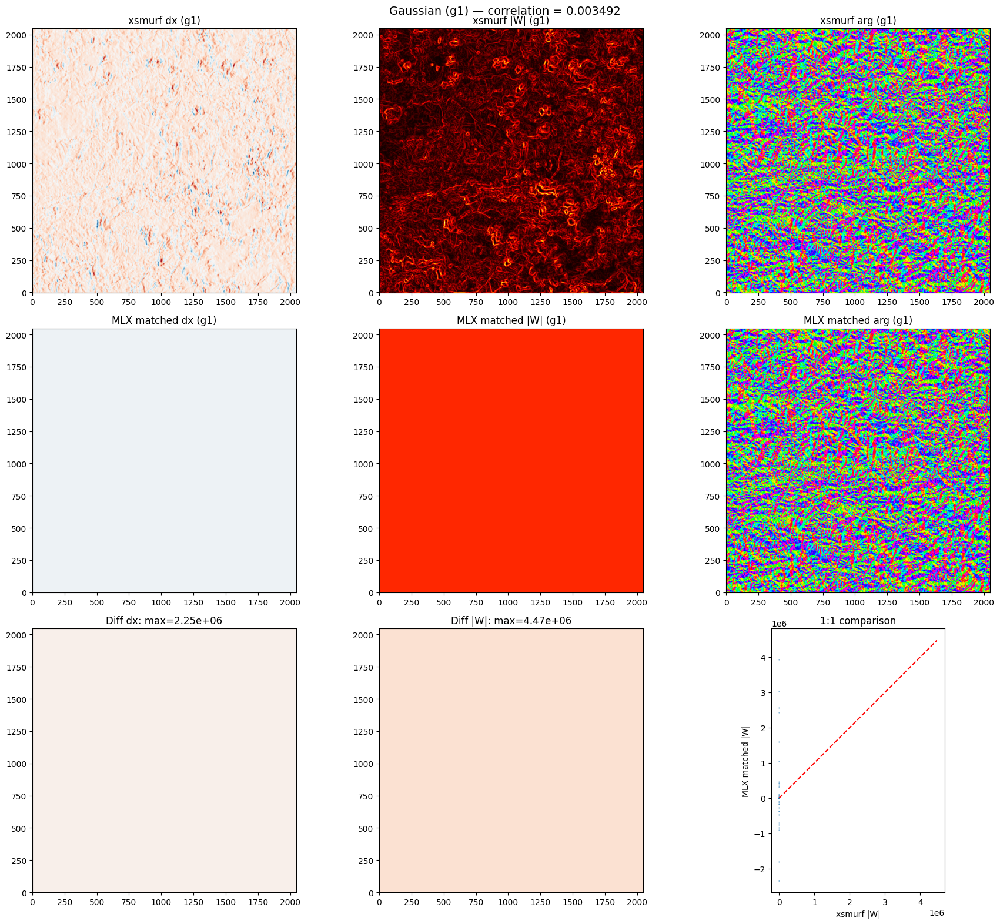


Gaussian dx: xsmurf max=19.885452, MLX max=2246295.250000, ratio=112961.734375
Gaussian mod: xsmurf max=25.020544, MLX max=4470385.000000


In [49]:
# ===== Compare Gaussian (g1) =====
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# Row 1: xsmurf
axes[0,0].imshow(dx_xsm_g, origin='lower', cmap='RdBu_r'); axes[0,0].set_title('xsmurf dx (g1)')
axes[0,1].imshow(mod_xsm_g, origin='lower', cmap='hot'); axes[0,1].set_title('xsmurf |W| (g1)')
axes[0,2].imshow(arg_xsm_g, origin='lower', cmap='hsv'); axes[0,2].set_title('xsmurf arg (g1)')

# Row 2: MLX matched
axes[1,0].imshow(dx_mlx_g, origin='lower', cmap='RdBu_r'); axes[1,0].set_title('MLX matched dx (g1)')
axes[1,1].imshow(mod_mlx_g, origin='lower', cmap='hot'); axes[1,1].set_title('MLX matched |W| (g1)')
axes[1,2].imshow(arg_mlx_g, origin='lower', cmap='hsv'); axes[1,2].set_title('MLX matched arg (g1)')

# Row 3: difference
diff_dx = dx_xsm_g - dx_mlx_g
diff_mod = mod_xsm_g - mod_mlx_g
axes[2,0].imshow(diff_dx, origin='lower', cmap='RdBu_r'); axes[2,0].set_title(f'Diff dx: max={np.abs(diff_dx).max():.2e}')
axes[2,1].imshow(diff_mod, origin='lower', cmap='RdBu_r'); axes[2,1].set_title(f'Diff |W|: max={np.abs(diff_mod).max():.2e}')

# Scatter: xsmurf vs MLX
axes[2,2].scatter(mod_xsm_g.ravel()[::100], mod_mlx_g.ravel()[::100], s=1, alpha=0.3)
lim = max(mod_xsm_g.max(), mod_mlx_g.max())
axes[2,2].plot([0, lim], [0, lim], 'r--')
axes[2,2].set(xlabel='xsmurf |W|', ylabel='MLX matched |W|', title='1:1 comparison')
axes[2,2].set_aspect('equal')

corr = np.corrcoef(mod_xsm_g.ravel(), mod_mlx_g.ravel())[0,1]
plt.suptitle(f'Gaussian (g1) — correlation = {corr:.6f}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nGaussian dx: xsmurf max={dx_xsm_g.max():.6f}, MLX max={dx_mlx_g.max():.6f}, ratio={dx_mlx_g.max()/dx_xsm_g.max():.6f}')
print(f'Gaussian mod: xsmurf max={mod_xsm_g.max():.6f}, MLX max={mod_mlx_g.max():.6f}')

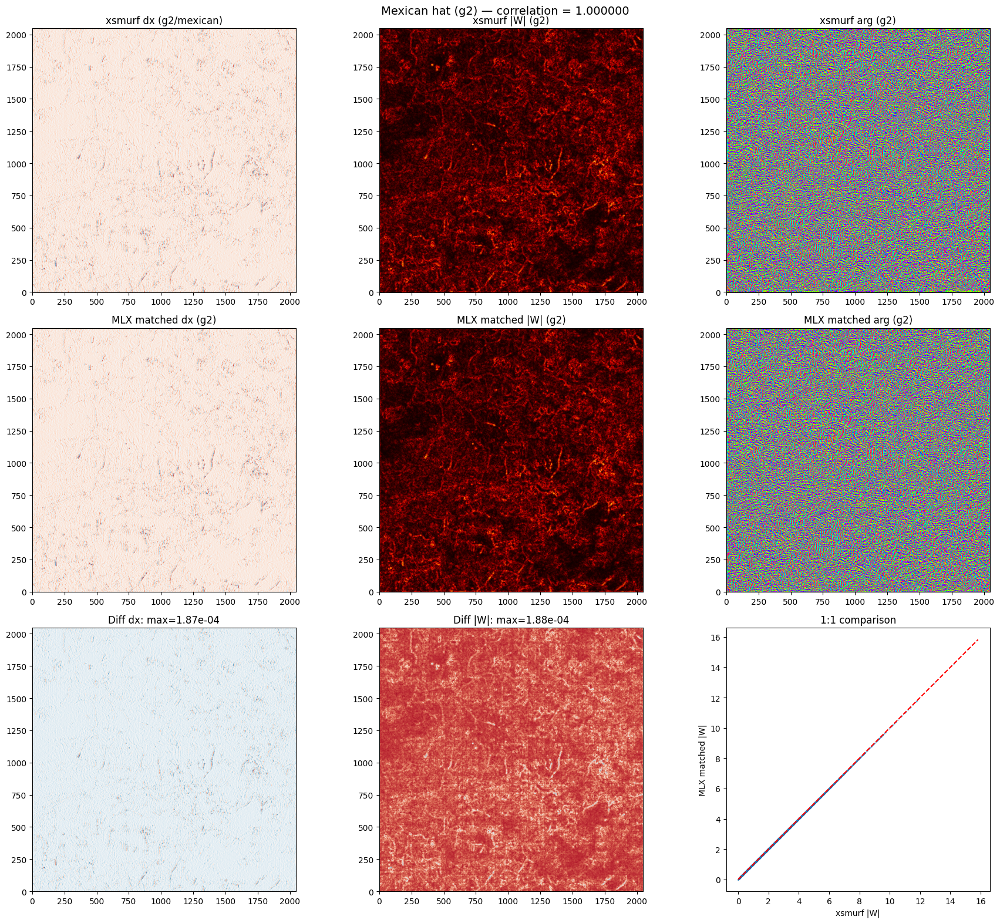


Mexican dx: xsmurf max=12.494018, MLX max=12.494152, ratio=1.000011


In [50]:
# ===== Compare Mexican hat (g2) =====
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

axes[0,0].imshow(dx_xsm_m, origin='lower', cmap='RdBu_r'); axes[0,0].set_title('xsmurf dx (g2/mexican)')
axes[0,1].imshow(mod_xsm_m, origin='lower', cmap='hot'); axes[0,1].set_title('xsmurf |W| (g2)')
axes[0,2].imshow(arg_xsm_m, origin='lower', cmap='hsv'); axes[0,2].set_title('xsmurf arg (g2)')

axes[1,0].imshow(dx_mlx_m, origin='lower', cmap='RdBu_r'); axes[1,0].set_title('MLX matched dx (g2)')
axes[1,1].imshow(mod_mlx_m, origin='lower', cmap='hot'); axes[1,1].set_title('MLX matched |W| (g2)')
axes[1,2].imshow(arg_mlx_m, origin='lower', cmap='hsv'); axes[1,2].set_title('MLX matched arg (g2)')

diff_dx_m = dx_xsm_m - dx_mlx_m
diff_mod_m = mod_xsm_m - mod_mlx_m
axes[2,0].imshow(diff_dx_m, origin='lower', cmap='RdBu_r'); axes[2,0].set_title(f'Diff dx: max={np.abs(diff_dx_m).max():.2e}')
axes[2,1].imshow(diff_mod_m, origin='lower', cmap='RdBu_r'); axes[2,1].set_title(f'Diff |W|: max={np.abs(diff_mod_m).max():.2e}')

axes[2,2].scatter(mod_xsm_m.ravel()[::100], mod_mlx_m.ravel()[::100], s=1, alpha=0.3)
lim_m = max(mod_xsm_m.max(), mod_mlx_m.max())
axes[2,2].plot([0, lim_m], [0, lim_m], 'r--')
axes[2,2].set(xlabel='xsmurf |W|', ylabel='MLX matched |W|', title='1:1 comparison')
axes[2,2].set_aspect('equal')

corr_m = np.corrcoef(mod_xsm_m.ravel(), mod_mlx_m.ravel())[0,1]
plt.suptitle(f'Mexican hat (g2) — correlation = {corr_m:.6f}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nMexican dx: xsmurf max={dx_xsm_m.max():.6f}, MLX max={dx_mlx_m.max():.6f}, ratio={dx_mlx_m.max()/dx_xsm_m.max():.6f}')

In [ ]:
# ===== Compare OLD MLX (2*pi, no swap) vs xsmurf =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(mod_xsm_g, origin='lower', cmap='hot'); axes[0].set_title('xsmurf |W| (g1)')
axes[1].imshow(mod_old, origin='lower', cmap='hot'); axes[1].set_title('OLD MLX |W| (2*pi, no swap)')

# Profile through the middle
mid = N // 2
axes[2].plot(mod_xsm_g[mid, :], 'b-', label='xsmurf', lw=2)
axes[2].plot(mod_mlx_g[mid, :], 'r--', label='MLX matched', lw=1.5)
axes[2].plot(mod_old[mid, :], 'g:', label='OLD MLX (2*pi)', lw=1.5)
axes[2].set(xlabel='x', ylabel='|W|', title='Profile y=N/2')
axes[2].legend()

plt.suptitle('Effect of 2*pi factor in frequency grid', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nPeak modulus comparison:')
print(f'  xsmurf:      {mod_xsm_g.max():.6f}')
print(f'  MLX matched:  {mod_mlx_g.max():.6f}  (ratio: {mod_mlx_g.max()/mod_xsm_g.max():.4f})')
print(f'  OLD MLX:      {mod_old.max():.6f}  (ratio: {mod_old.max()/mod_xsm_g.max():.4f})')

In [ ]:
# ===== Multi-scale comparison =====
# Check if the SLOPE of log|W| vs log(a) matches between implementations
norm_factor = 6.0 / 0.86
test_scales = [norm_factor * 2**(o + v/4) for o in range(4) for v in range(4)]

# Pick a point: the step edge center
py, px = N//2, N//2

mod_vs_scale_xsm = []
mod_vs_scale_mlx = []
mod_vs_scale_old = []

for s in test_scales:
    # xsmurf
    fd = fft_xsm.duplicate()
    xsm.fftw_convolve(fd, 'dx', s)
    dxs = xsm.ifftw_inverse(fd).to_numpy()
    fd = fft_xsm.duplicate()
    xsm.fftw_convolve(fd, 'dy', s)
    dys = xsm.ifftw_inverse(fd).to_numpy()
    mod_vs_scale_xsm.append(np.sqrt(dxs[py,px]**2 + dys[py,px]**2))
    
    # MLX matched
    KXs = mx.array((KX_np * s).astype(np.float32))
    KYs = mx.array((KY_np * s).astype(np.float32))
    gs = mx.exp(-(KXs*KXs + KYs*KYs))
    px_hat = mx.array(np.stack([np.zeros_like(np.array(gs)), np.array(KXs*gs)], axis=-1)).view(mx.complex64).squeeze(-1)
    py_hat = mx.array(np.stack([np.zeros_like(np.array(gs)), np.array(KYs*gs)], axis=-1)).view(mx.complex64).squeeze(-1)
    dxm = np.array(mx.fft.ifft2(image_fft * px_hat).real)
    dym = np.array(mx.fft.ifft2(image_fft * py_hat).real)
    mod_vs_scale_mlx.append(np.sqrt(dxm[py,px]**2 + dym[py,px]**2))
    
    # OLD MLX (2*pi)
    KXo = mx.array((KX_old * s / scale).astype(np.float32))  # rescale
    KYo = mx.array((KY_old * s / scale).astype(np.float32))
    go = mx.exp(-(KXo*KXo + KYo*KYo))
    px_o = mx.array(np.stack([np.zeros_like(np.array(go)), np.array(KXo*go)], axis=-1)).view(mx.complex64).squeeze(-1)
    py_o = mx.array(np.stack([np.zeros_like(np.array(go)), np.array(KYo*go)], axis=-1)).view(mx.complex64).squeeze(-1)
    dxo = np.array(mx.fft.ifft2(image_fft * px_o).real)
    dyo = np.array(mx.fft.ifft2(image_fft * py_o).real)
    mod_vs_scale_old.append(np.sqrt(dxo[py,px]**2 + dyo[py,px]**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log2_s = np.log2(test_scales)
log2_mod_xsm = np.log2(np.maximum(mod_vs_scale_xsm, 1e-30))
log2_mod_mlx = np.log2(np.maximum(mod_vs_scale_mlx, 1e-30))
log2_mod_old = np.log2(np.maximum(mod_vs_scale_old, 1e-30))

axes[0].plot(log2_s, log2_mod_xsm, 'b.-', label='xsmurf FFTW', lw=2)
axes[0].plot(log2_s, log2_mod_mlx, 'r.--', label='MLX matched')
axes[0].plot(log2_s, log2_mod_old, 'g.:', label='OLD MLX (2*pi)')
axes[0].set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'|W| vs scale at pixel ({px},{py})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Slopes
from numpy.polynomial.polynomial import polyfit
if len(log2_s) > 2:
    slope_xsm = np.polyfit(log2_s, log2_mod_xsm, 1)[0]
    slope_mlx = np.polyfit(log2_s, log2_mod_mlx, 1)[0]
    slope_old = np.polyfit(log2_s, log2_mod_old, 1)[0]
    
    axes[1].bar(['xsmurf', 'MLX matched', 'OLD MLX'], [slope_xsm, slope_mlx, slope_old],
               color=['steelblue', 'coral', 'green'])
    axes[1].set(ylabel='slope (= h + offset)', title='Slope of log|W| vs log(a)')
    axes[1].grid(True, alpha=0.3)
    
    print(f'Slopes at pixel ({px},{py}):')
    print(f'  xsmurf:     {slope_xsm:.4f}')
    print(f'  MLX matched: {slope_mlx:.4f}')
    print(f'  OLD MLX:     {slope_old:.4f}')

plt.tight_layout()
plt.show()